# Xception Mimari Modeli - Nihai Test Seti Değerlendirmesi

Bu araştırma günlüğü, tamamen **Xception** mimarisine odaklanarak eğitilmiş olan `best_xception_model.pth` ağırlıklarının, modelin eğitim esnasında **hiç görmediği** `%15'lik Test Seti` üzerindeki performansını ölçmek amacıyla hazırlanmıştır.

**Değerlendirme Kapsamı:**
1. Test Verilerinin Yüklenmesi (Xception Standartlarında 299x299 ve [-1, 1] Normalizasyonu)
2. Sınıflandırma Raporu (Accuracy, Precision, Recall, F1-Score)
3. Karmaşıklık Matrisi (Confusion Matrix)
4. ROC Eğrisi ve AUC Skorunun Hesaplanması
5. Açıklanabilir Yapay Zeka (XAI - Grad-CAM) Analizi

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from torch.utils.data import DataLoader

# Kod değişikliklerini anlık algılaması için autoreload modunu açalım
%load_ext autoreload
%autoreload 2

# Üst dizindeki src klasörüne erişim sağlayalım
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# Katmanlı mimari bileşenlerimizi import edelim
from src.models import XceptionDetector
from src.dataset import DeepfakeDataset, get_transforms
from src.evaluation import calculate_metrics, plot_confusion_matrix, get_gradcam_visualization
from src.utils import get_device

device = get_device()
print(f"🚀 Analiz İçin Hazırlanan Cihaz: {device}")

🚀 Analiz İçin Hazırlanan Cihaz: cuda


In [2]:
# Parametreler
MODEL_PATH = "../checkpoints/xception1/best_xception_model.pth"
DATA_DIR = "../data/processed"
BATCH_SIZE = 4 # Bellek optimizasyonu için
IMG_SIZE = 299 # Xception standart boyutu

# 1. Model Katmanını Yükleyelim
model = XceptionDetector(pretrained=False)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("✅ En iyi Xception model ağırlıkları başarıyla yüklendi.")
else:
    raise FileNotFoundError(f"❌ Belirtilen model dosyası bulunamadı: {MODEL_PATH}")
model.to(device).eval()

# 2. Veri Katmanını Yükleyelim (Sadece TEST fazı)
test_dataset = DeepfakeDataset(root_dir=DATA_DIR, phase="test", transform=get_transforms(img_size=IMG_SIZE, phase="test"))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

c:\Users\ENES\Desktop\xception\.venv\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
C:\Users\ENES\AppData\Local\Temp\ipykernel_5560\106506710.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't h

✅ En iyi Xception model ağırlıkları başarıyla yüklendi.
📊 [TEST] Seti Hazır: 2452 adet yüz görüntüsü sisteme yüklendi.


In [3]:
all_labels = []
all_preds = []
all_probs = []

print("🔬 Test seti üzerinde model tahmini başlatıldı...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.flatten())
        all_probs.extend(probs.flatten())

print("✅ Tüm tahminler başarıyla toplandı.")

🔬 Test seti üzerinde model tahmini başlatıldı...
✅ Tüm tahminler başarıyla toplandı.


## 1. Akademik Başarı Metrikleri ve Sınıflandırma Raporu

Aşağıdaki hücrede modelin test setindeki genel doğruluğu, sınıflara göre kesinlik (precision) ve duyarlılık (recall) dengesi incelenmiştir.

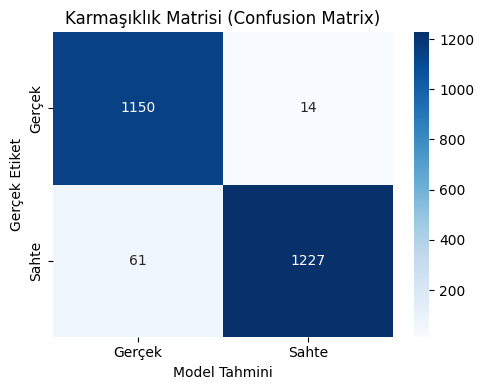


📋 Detaylı Sınıflandırma Raporu:
               precision    recall  f1-score   support

Gerçek (Real)       0.95      0.99      0.97      1164
 Sahte (Fake)       0.99      0.95      0.97      1288

     accuracy                           0.97      2452
    macro avg       0.97      0.97      0.97      2452
 weighted avg       0.97      0.97      0.97      2452



In [4]:
# Katmanlı mimarideki merkezi fonksiyonumuzu çağırarak matrisi çizelim
fig = plot_confusion_matrix(all_labels, all_preds)
plt.show()

# Detaylı sklearn classification report çıktısı
print("\n📋 Detaylı Sınıflandırma Raporu:")
print(classification_report(all_labels, all_preds, target_names=['Gerçek (Real)', 'Sahte (Fake)']))

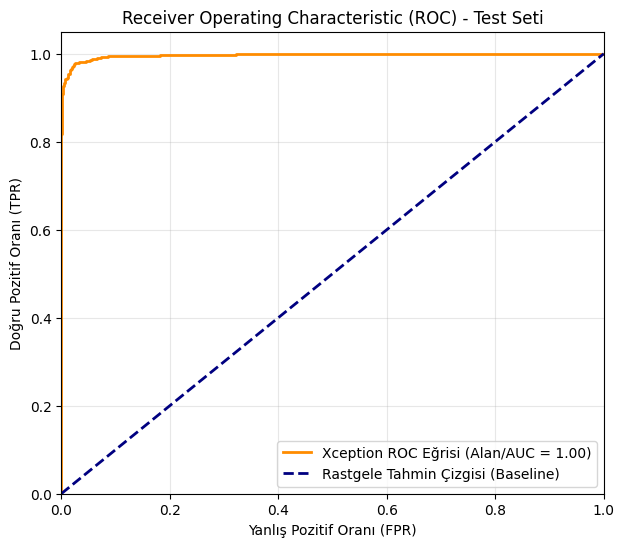

In [5]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Xception ROC Eğrisi (Alan/AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin Çizgisi (Baseline)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Test Seti')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 2. Açıklanabilir Yapay Zeka (XAI) ve Model Karar Mekanizması Analizi

Modelin test setinde "Sahte" (Fake) olarak sınıflandırdığı örneklerin pikselsel bazda analizini yapmak ve ağın yüz yapısındaki hangi manipülasyon izlerine odaklandığını görmek için **Grad-CAM** görselleştirmesi uygulanmıştır.

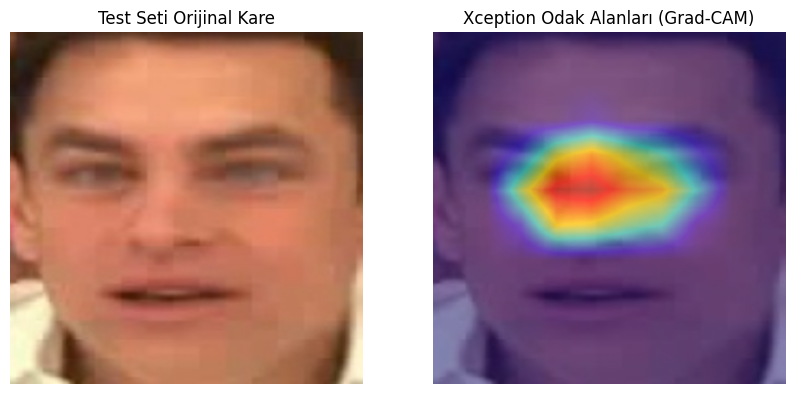

In [6]:
# Test setindeki sahte (Fake) sınıfa ait başarılı bir tahmini yakalayalım
fake_indices = [i for i, label in enumerate(all_labels) if label == 1 and all_preds[i] == 1]

if len(fake_indices) > 0:
    target_idx = fake_indices[0] # İlk yakalanan doğru sahte tahminini inceleyelim
    
    # Dataset'ten ham veriyi alalım
    image_tensor, label = test_dataset[target_idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Görselleştirme için resmi tensor formatından numpy formatına geri getirelim
    face_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    # Görüntü normalizasyonunu tersine çeviriyoruz ([-1, 1] -> [0, 255])
    orig_img = (((face_np * 0.5) + 0.5) * 255).astype(np.uint8)
    
    # src/evaluation.py içerisindeki Grad-CAM fonksiyonunu çağıralım
    cam_viz = get_gradcam_visualization(model, input_tensor, orig_img)
    
    # Yan yana çizim yapalım
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_img)
    plt.title("Test Seti Orijinal Kare")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cam_viz)
    plt.title("Xception Odak Alanları (Grad-CAM)")
    plt.axis('off')
    plt.show()
else:
    print("İncelenecek uygun sahte tahmin örneği test setinde bulunamadı.")

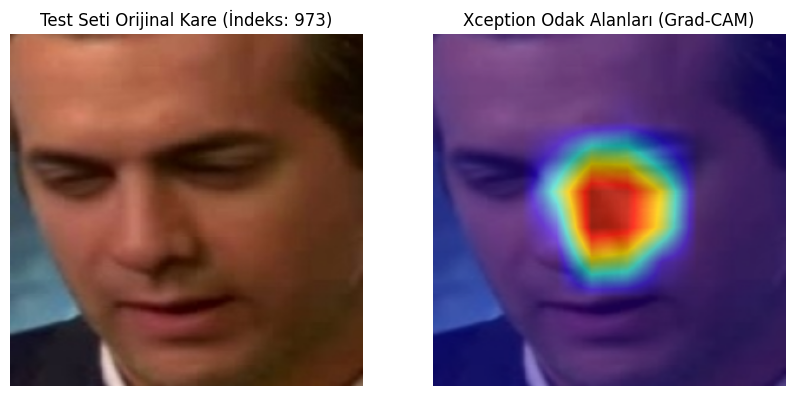

In [7]:
import random

# Test setindeki sahte (Fake) sınıfa ait başarılı tahminlerin TÜM indekslerini yakalayalım
fake_indices = [i for i, label in enumerate(all_labels) if label == 1 and all_preds[i] == 1]

if len(fake_indices) > 0:
    # Sabit indeks [0] yerine, listeden HER SEFERİNDE RASTGELE BİR İNDEKS seçiyoruz
    target_idx = random.choice(fake_indices) 
    
    # Dataset'ten rastgele seçilen ham veriyi alalım
    image_tensor, label = test_dataset[target_idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Görselleştirme için resmi tensor formatından numpy formatına geri getirelim
    face_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    
    # Görüntü normalizasyonunu tersine çeviriyoruz ([-1, 1] -> [0, 255])
    orig_img = (((face_np * 0.5) + 0.5) * 255).astype(np.uint8)
    
    # src/evaluation.py içerisindeki dinamik Grad-CAM fonksiyonunu çağıralım
    cam_viz = get_gradcam_visualization(model, input_tensor, orig_img)
    
    # Yan yana çizim yapalım
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_img)
    plt.title(f"Test Seti Orijinal Kare (İndeks: {target_idx})")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cam_viz)
    plt.title("Xception Odak Alanları (Grad-CAM)")
    plt.axis('off')
    plt.show()
else:
    print("İncelenecek uygun sahte tahmin örneği test setinde bulunamadı.")

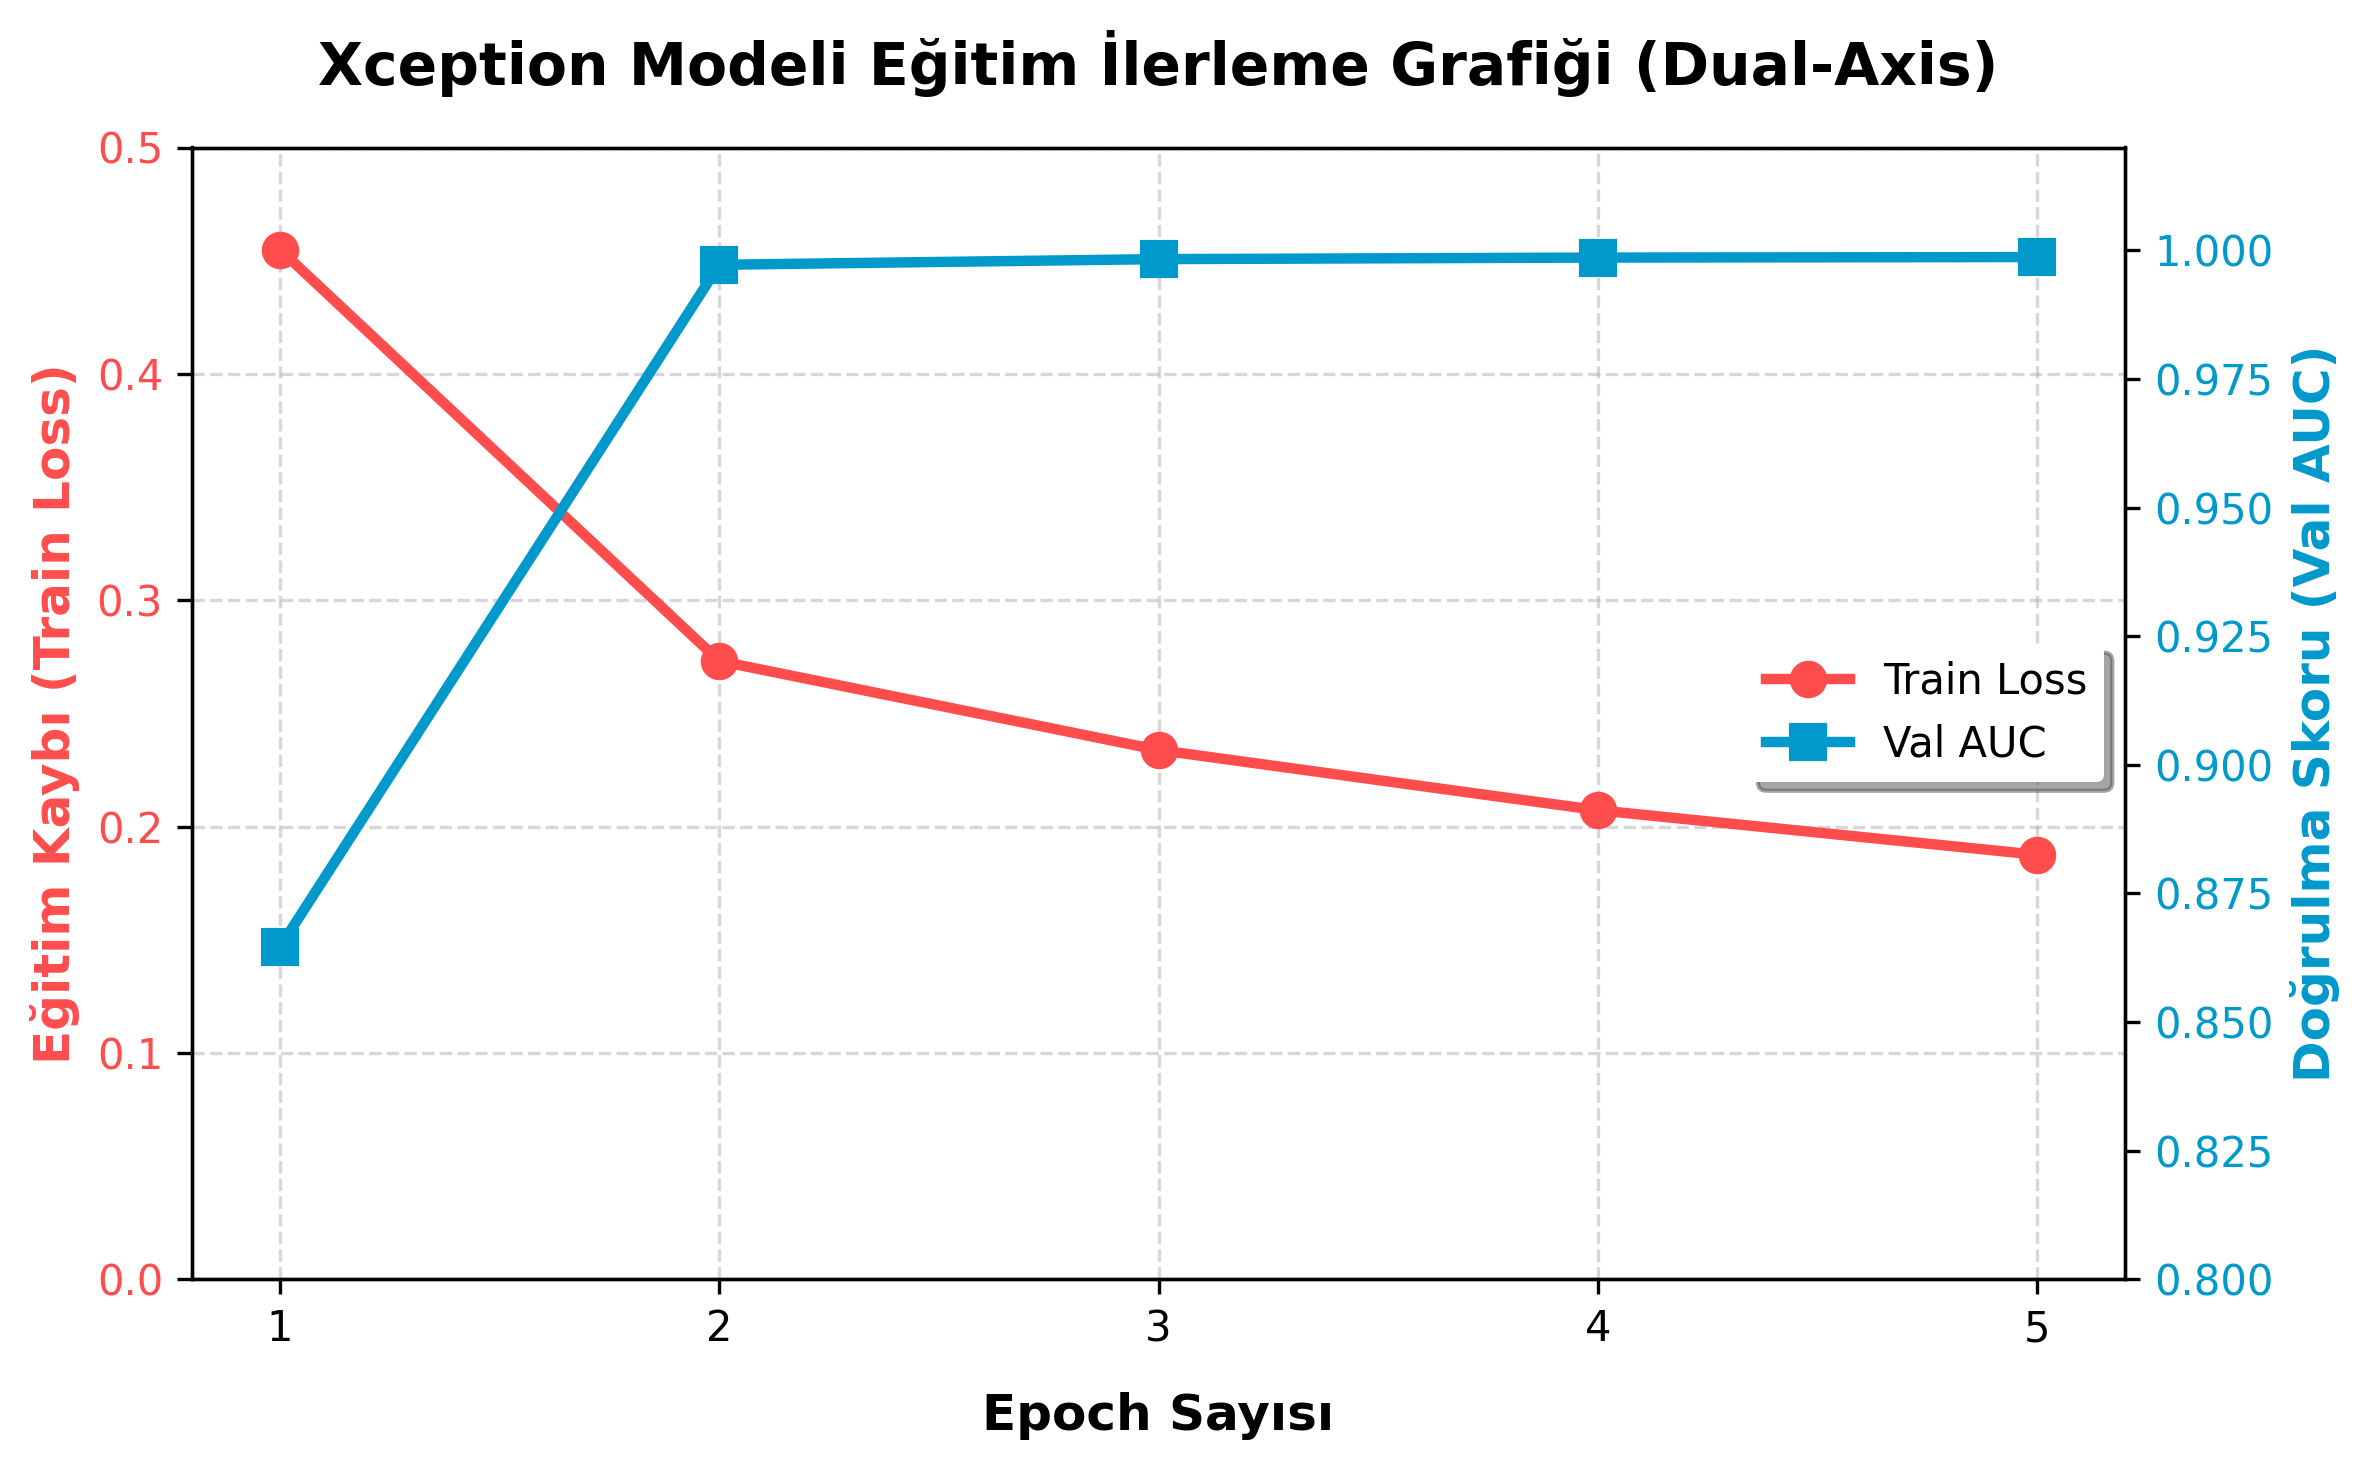

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Notlarında yer alan 5 Epochluk resmi eğitim verileri
epochs = np.array([1, 2, 3, 4, 5])
train_loss = np.array([0.4549, 0.2731, 0.2338, 0.2072, 0.1875])
val_auc = np.array([0.8646, 0.9972, 0.9983, 0.9986, 0.9987])

# Grafik çözünürlüğünü ve boyutunu sunum kalitesine ayarlayalım (DPI=300)
fig, ax1 = plt.subplots(figsize=(8, 5), dpi=300)

# --- SOL EKSEN: Train Loss Çizimi ---
color = '#ff4d4d' # Mühendislik kırmızısı
ax1.set_xlabel('Epoch Sayısı', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Eğitim Kaybı (Train Loss)', color=color, fontsize=12, fontweight='bold')
plot_loss = ax1.plot(epochs, train_loss, color=color, marker='o', linewidth=2.5, markersize=8, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5) # Arka plan kılavuz çizgileri

# --- SAĞ EKSEN: Validation AUC Çizimi ---
# twinx() fonksiyonu aynı X eksenini paylaşan bağımsız bir sağ Y ekseni açar
ax2 = ax1.twinx()  
color = '#0099cc' # Adli bilişim mavisi
ax2.set_ylabel('Doğrulma Skoru (Val AUC)', color=color, fontsize=12, fontweight='bold')
plot_auc = ax2.plot(epochs, val_auc, color=color, marker='s', linewidth=2.5, markersize=8, label='Val AUC')
ax2.tick_params(axis='y', labelcolor=color)

# Eksen sınırlarını verilerin doğasına göre optimize edelim
ax1.set_ylim([0, 0.5]) # Loss düşüşünü net göstermek için
ax2.set_ylim([0.8, 1.02]) # AUC kararlılığını zirvede göstermek için
plt.xticks(epochs)

# --- Ortak Lejant (Legend) Tasarımı ---
# İki farklı eksendeki etiketleri tek bir kutuda topluyoruz
plots = plot_loss + plot_auc
labels = [p.get_label() for p in plots]
ax1.legend(plots, labels, loc='center right', frameon=True, facecolor='white', edgecolor='none', shadow=True)

# Grafik Başlığı
plt.title('Xception Modeli Eğitim İlerleme Grafiği (Dual-Axis)', fontsize=14, fontweight='bold', pad=15)

# Görsel çakışmaları önlemek için sıkı yerleşim
plt.tight_layout()

# Sunum slaytına doğrudan ekleyebilmek için yüksek kalitede kaydetme
os.makedirs('outputs', exist_ok=True)
fig.savefig('outputs/training_evaluation_curve.png', bbox_inches='tight', dpi=300)
plt.show()

🎯 Dinamik Olarak Seçilen Adli Kanıt Görseli: ../data/processed/test/Fake\id2_id30_0009\frame_0.jpg


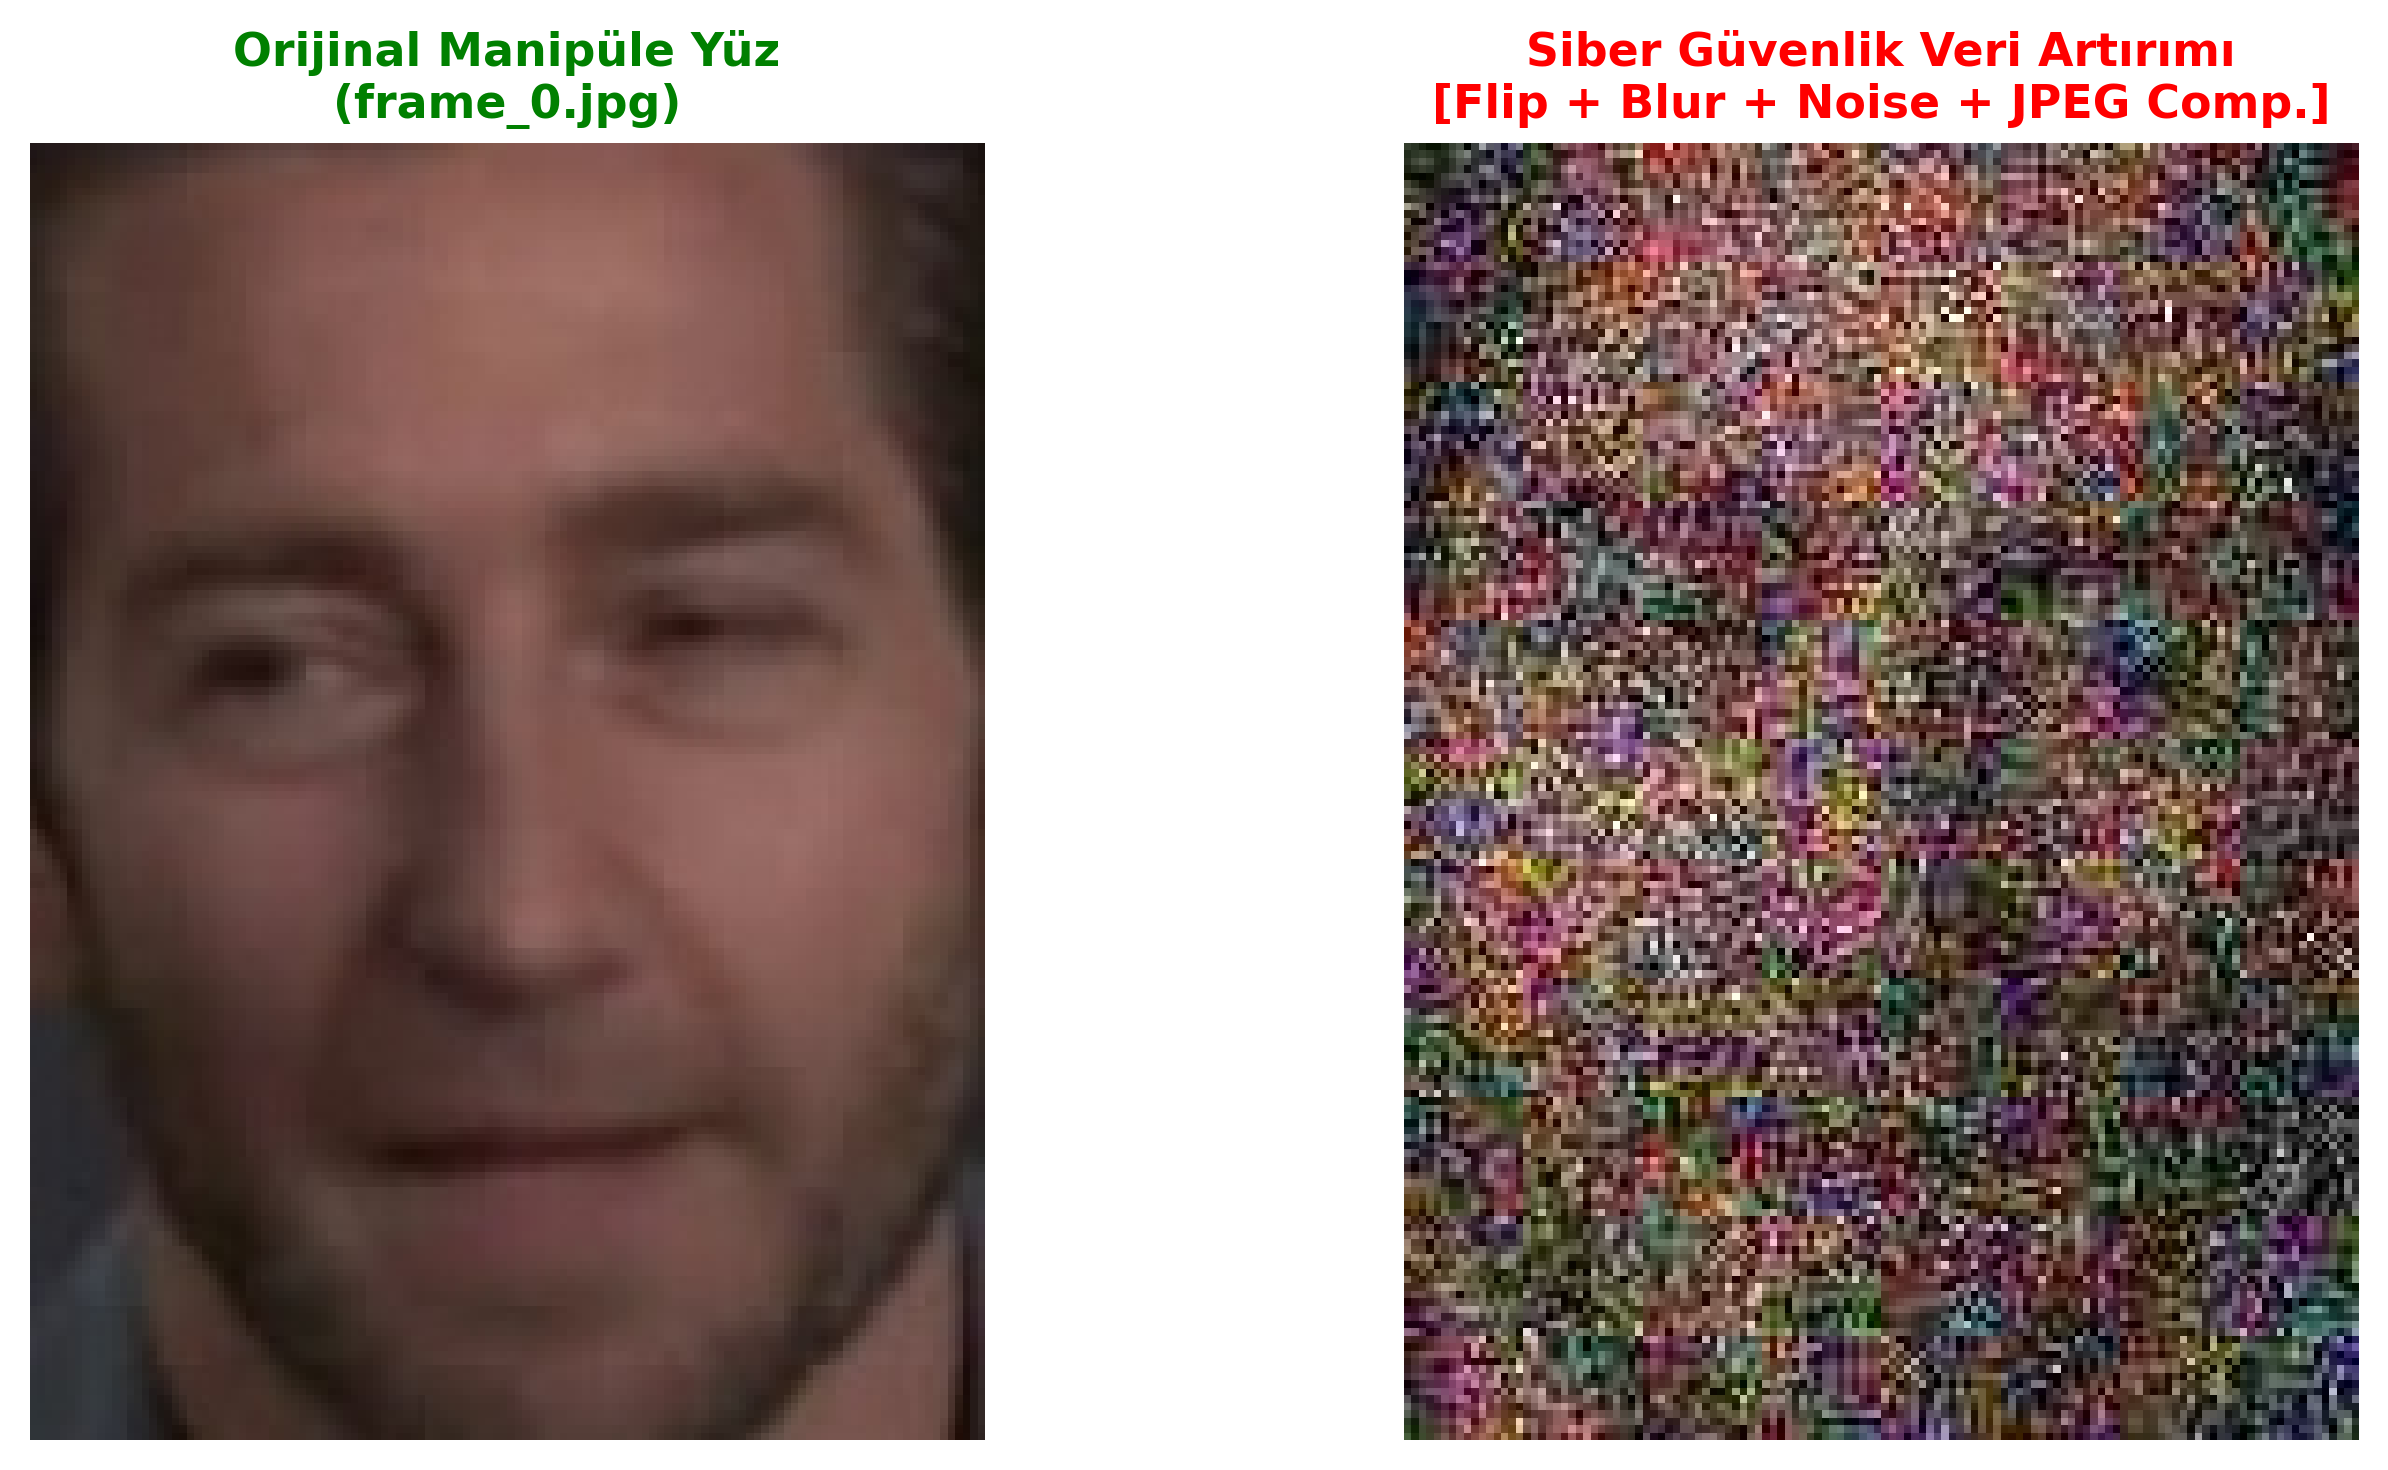

📊 Grafik '../outputs\data_augmentation_visual.png' olarak başarıyla mühürlendi!


In [13]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A

# 1. Albumentations Filtre Hattının Tam Kararlı Hale Getirilmesi
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.GaussianBlur(blur_limit=(3, 7), p=1.0),
    # Uyarıları engellemek için parametresiz en kararlı hali seçildi
    A.GaussNoise(p=1.0),
    A.ImageCompression(quality_range=(20, 30), p=1.0)
])

# 2. Notebook Konumuna Göre Üst Dizine Çıkış Kontrolü (../ eklendi)
base_fake_path = '../data/processed/test/Fake'

# Eğer notebooks klasöründe değil de ana dizindeysen diye alternatif kontrol
if not os.path.exists(base_fake_path):
    base_fake_path = 'data/processed/test/Fake'

if os.path.exists(base_fake_path):
    sub_folders = [f for f in os.listdir(base_fake_path) if os.path.isdir(os.path.join(base_fake_path, f))]
    
    if len(sub_folders) > 0:
        random_folder = random.choice(sub_folders)
        target_folder_path = os.path.join(base_fake_path, random_folder)
        
        all_frames = [img for img in os.listdir(target_folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if len(all_frames) > 0:
            random_frame = random.choice(all_frames)
            sample_image_path = os.path.join(target_folder_path, random_frame)
            
            print(f"🎯 Dinamik Olarak Seçilen Adli Kanıt Görseli: {sample_image_path}")
            
            # 3. Görüntü Okuma ve Renk Uzayı Dönüşümü
            image = cv2.imread(sample_image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Filtreleri uygulama
            augmented = aug_pipeline(image=image)
            augmented_image = augmented['image']
            
            # 4. Yüksek Kaliteli (DPI=300) Görselleştirme Alanı
            fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)
            
            # Sol Taraf: Orijinal Sahte Yüz Hücresi
            axes[0].imshow(image)
            axes[0].set_title(f"Orijinal Manipüle Yüz\n({random_frame})", fontsize=11, fontweight='bold', color='green')
            axes[0].axis('off')
            
            # Sağ Taraf: Albumentations Ağ Sıkıştırma Simülasyonu
            axes[1].imshow(augmented_image)
            axes[1].set_title("Siber Güvenlik Veri Artırımı\n[Flip + Blur + Noise + JPEG Comp.]", fontsize=11, fontweight='bold', color='red')
            axes[1].axis('off')
            
            plt.tight_layout()
            
            # Çıktıyı kaydetme (Kök dizindeki outputs klasörüne gider)
            output_dir = '../outputs' if 'data' in base_fake_path and '../' in base_fake_path else 'outputs'
            os.makedirs(output_dir, exist_ok=True)
            plt.savefig(os.path.join(output_dir, 'data_augmentation_visual.png'), bbox_inches='tight', dpi=300)
            plt.show()
            print(f"📊 Grafik '{os.path.join(output_dir, 'data_augmentation_visual.png')}' olarak başarıyla mühürlendi!")
        else:
            print(f"❌ Hata: '{target_folder_path}' klasörünün içinde hiç karesel görsel bulunamadı.")
    else:
        print(f"❌ Hata: '{base_fake_path}' dizininin altında hiçbir alt klasör bulunamadı.")
else:
    print(f"❌ Hata: Ana dizin yolu sistemde tespit edilemedi: '{base_fake_path}'.")

🎯 Analiz Edilecek Adli Kare: ../data/processed/test/Fake\id1_id26_0000\frame_240.jpg


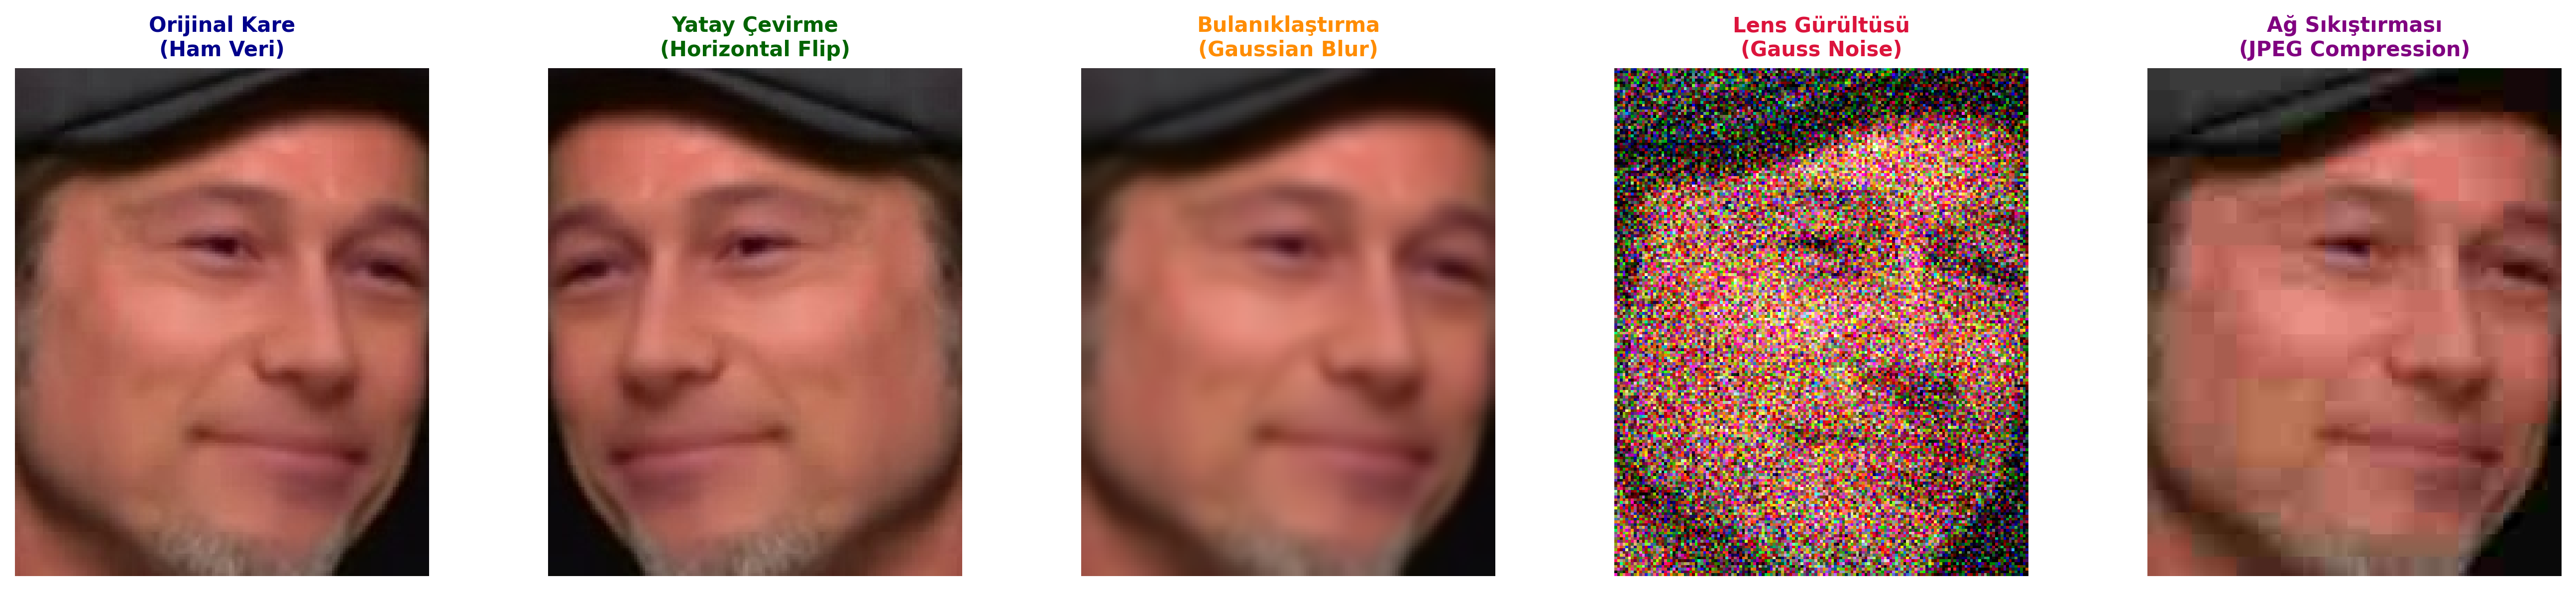

📊 Veri artırma matrisi '../outputs\data_augmentation_matrix.png' olarak başarıyla mühürlendi!


In [14]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A

# 1. Her bir filtreyi tek tek görselleştirmek için bağımsız Albumentations nesneleri
flip_aug = A.HorizontalFlip(p=1.0)
blur_aug = A.GaussianBlur(blur_limit=(5, 9), p=1.0)
noise_aug = A.GaussNoise(p=1.0)
compress_aug = A.ImageCompression(quality_range=(15, 25), p=1.0)

# 2. Üst Dizine Çıkış Kontrolü ve Dinamik Dosya Tarama (../ eklendi)
base_fake_path = '../data/processed/test/Fake'

if not os.path.exists(base_fake_path):
    base_fake_path = 'data/processed/test/Fake'

if os.path.exists(base_fake_path):
    sub_folders = [f for f in os.listdir(base_fake_path) if os.path.isdir(os.path.join(base_fake_path, f))]
    
    if len(sub_folders) > 0:
        random_folder = random.choice(sub_folders)
        target_folder_path = os.path.join(base_fake_path, random_folder)
        all_frames = [img for img in os.listdir(target_folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if len(all_frames) > 0:
            random_frame = random.choice(all_frames)
            sample_image_path = os.path.join(target_folder_path, random_frame)
            
            print(f"🎯 Analiz Edilecek Adli Kare: {sample_image_path}")
            
            # Görüntüyü Oku ve RGB'ye Çevir
            img = cv2.imread(sample_image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # 3. Filtreleri Tek Tek Uygula
            img_flip = flip_aug(image=img)['image']
            img_blur = blur_aug(image=img)['image']
            img_noise = noise_aug(image=img)['image']
            img_comp = compress_aug(image=img)['image']
            
            # 4. Matris Düzeni Oluşturma (1 Satır, 5 Sütun)
            fig, axes = plt.subplots(1, 5, figsize=(18, 4), dpi=300)
            
            # [0] Orijinal Kare
            axes[0].imshow(img)
            axes[0].set_title("Orijinal Kare\n(Ham Veri)", fontsize=10, fontweight='bold', color='darkblue')
            axes[0].axis('off')
            
            # [1] Horizontal Flip
            axes[1].imshow(img_flip)
            axes[1].set_title("Yatay Çevirme\n(Horizontal Flip)", fontsize=10, fontweight='bold', color='darkgreen')
            axes[1].axis('off')
            
            # [2] Gaussian Blur
            axes[2].imshow(img_blur)
            axes[2].set_title("Bulanıklaştırma\n(Gaussian Blur)", fontsize=10, fontweight='bold', color='darkorange')
            axes[2].axis('off')
            
            # [3] Gauss Noise
            axes[3].imshow(img_noise)
            axes[3].set_title("Lens Gürültüsü\n(Gauss Noise)", fontsize=10, fontweight='bold', color='crimson')
            axes[3].axis('off')
            
            # [4] JPEG Compression
            axes[4].imshow(img_comp)
            axes[4].set_title("Ağ Sıkıştırması\n(JPEG Compression)", fontsize=10, fontweight='bold', color='purple')
            axes[4].axis('off')
            
            plt.tight_layout()
            
            # Çıktıyı kaydetme
            output_dir = '../outputs' if 'data' in base_fake_path and '../' in base_fake_path else 'outputs'
            os.makedirs(output_dir, exist_ok=True)
            output_file = os.path.join(output_dir, 'data_augmentation_matrix.png')
            plt.savefig(output_file, bbox_inches='tight', dpi=300)
            plt.show()
            
            print(f"📊 Veri artırma matrisi '{output_file}' olarak başarıyla mühürlendi!")
        else:
            print(f"❌ Hata: Klasör boş.")
    else:
        print(f"❌ Hata: Alt klasör bulunamadı.")
else:
    print(f"❌ Hata: Ana dizin yolu bulunamadı: '{base_fake_path}'")